# Error Analysis

This notebook will be used to perform data alaysis of prediction errors. 
- Which attribute types had more errors/correct predictions?
    - Per model and template?

In [41]:
# enable autoreload so imported modules refresh automatically after installs/edits
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
# !uv add matplotlib

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
raw_results_analysis =pd.read_csv("../results/prompt_selection/portuguese/detailed_results.csv")
raw_results_analysis.head()

,modelo,entity,doc_id,template,token,pred_type,annt_type,result,f1_r_score
0,gemini,participants,lusa_1,cls,estabelecimento de bebidas,Fac,Fac,tp,NaN
1,gemini,participants,lusa_1,cls,Corotelo,Loc,Pl_civil,tp,NaN
2,gemini,participants,lusa_1,cls,concelho de São Brás de Alportel,Loc,Pl_civil,tp,NaN
3,gemini,participants,lusa_1,cls,militares,Per,Per,tp,NaN
4,gemini,participants,lusa_1,cls,bar,Fac,Fac,tp,NaN


In [48]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df = raw_results_analysis.copy()
df['annt_type'] = df['annt_type'].fillna('MISSING')

counts = (
    df
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot = counts.sort_values(['annt_type', 'template', 'result'])
df_sorted = pivot.sort_values(by='count', ascending=False)
df_sorted_tp = df_sorted[df_sorted['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn = df_sorted_tp.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn.head(50))

,modelo,annt_type,template,count_tp_fn,count_tp
0,gemini,Fac,cls,37,6
1,gemini,Fac,cls_def,37,5
2,gemini,Fac,cls_def_exp,37,15
3,gemini,Fac,cls_exp,37,13
4,gemini,Fac,ext,38,0
5,gemini,Fac,ext_def,38,0
6,gemini,Fac,ext_def_exp,38,0
7,gemini,Fac,ext_exp,38,0
8,gemini,Loc,cls,41,9
9,gemini,Loc,cls_def,41,9


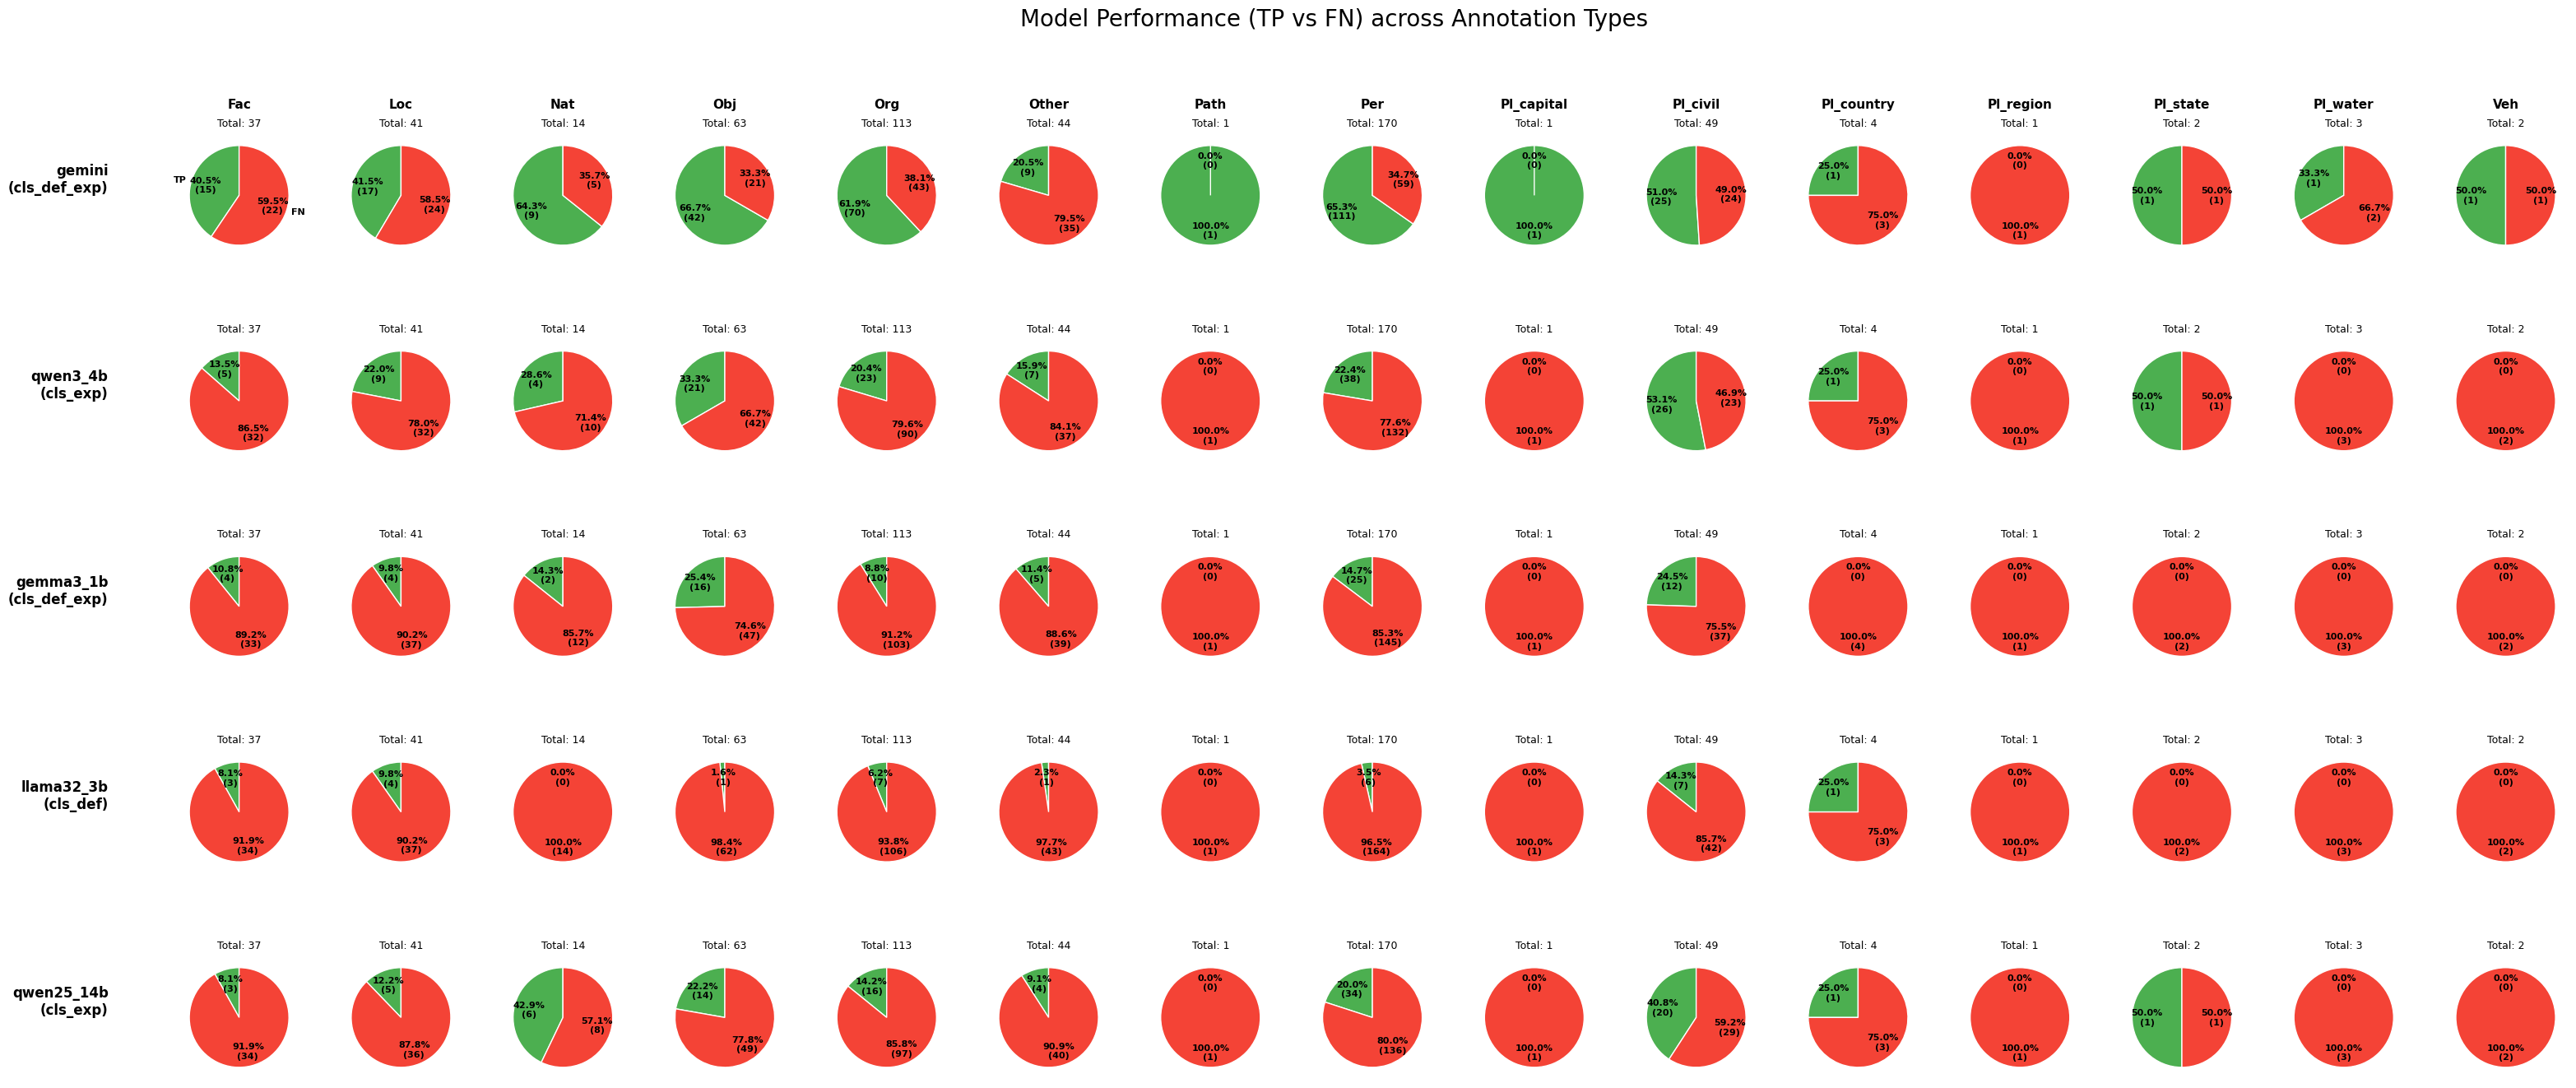

In [55]:
# 1. Define the targets and annotation types
targets = [
    ("gemini", "cls_def_exp"),
    ("qwen3_4b", "cls_exp"),
    ("gemma3_1b", "cls_def_exp"),
    ("llama32_3b", "cls_def"),
    ("qwen25_14b", "cls_exp")
]

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn[
            (df_sorted_tp_fn['modelo'] == modelo) & 
            (df_sorted_tp_fn['template'] == template) & 
            (df_sorted_tp_fn['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()